# Implement an Orchestrator Workflow for Report Generation With OpenAI Agents SDK and LangGraph

## Overview

So far you have learned about three **agentic design patterns**:

- **Prompt chaining** (deterministic workflows)
- **Routing** (conditional branching)
- **Parallelization** (concurrent execution)

For all three patterns, the workflow structure was fixed at design time. With prompt chaining, every input follows the same steps. With routing, the branches are predefined. With parallelization, the parallel tasks are known in advance.

But what if the workflow itself needs to be dynamic? What if an orchestrator needs to analyze the task, decide how to break it down, and delegate to the right workers? That’s exactly what the **orchestrator workflow** agentic design pattern is designed for dynamic task planning.

In this activity, you’ll explore the orchestrator workflow pattern by building agentic workflows with a central orchestrator, using both the OpenAI Agents SDK and LangGraph.

## Orchestrator Workflow

**What is an Orchestrator Workflow?**

An orchestrator workflow is a pattern where a central "orchestrator" agent analyzes a task, creates a plan, delegates work to specialized "worker" agents, and then synthesizes the results. Think of it as a project manager: They don't do all the work themselves, but they understand the goal, break it into pieces, assign the right people, and pull everything together at the end.

**The Three Roles:**

1. **Orchestrator (Planner)**: Analyzes the task, breaks it into subtasks, creates a structured plan
2. **Workers**: Execute individual subtasks according to the plan
3. **Synthesizer**: Combines worker outputs into the final result

**Orchestrator vs. Parallelization: When to Use Which?**

This is a crucial distinction. In the **parallelization** pattern, the subtasks are **predefined at design time**. You know in advance that you'll run three agents (like summary, key points, sentiment) on every input.

In the **orchestrator workflow** pattern, it's okay for the subtasks **to not be predefined**. The orchestrator must analyze the input to determine what work needs to be done. As the LangGraph documentation explains:

> "Orchestrator-worker workflows provide more flexibility and are often used when subtasks cannot be predefined the way they can with parallelization."

**Examples to illustrate the difference:**

| Scenario | Pattern | Why? |
|----------|---------|------|
| Analyze a document for summary, key points, sentiment | Parallelization | Always the same 3 tasks |
| Translate text to N languages (user specifies which) | Orchestrator | Don't know which/how many languages until runtime |
| Generate a report with planned sections | Orchestrator | Section topics depend on the subject matter |
| Update installation docs across unknown # of files | Orchestrator | Can't predict which files need updates |
| Run content generation + safety guardrails | Parallelization | Always the same 2-3 checks |

**The Key Insight:**

If you find yourself thinking, "I need to loop over something the LLM identified and use appropriate tools on the basis of it," you probably need an orchestrator. If you always run the same set of agents regardless of input, you can use parallelization.

**Real-World Examples:**

- **Multi-Language Translation**: The orchestrator identifies target languages from the request, delegates to translator workers for each language, then formats the combined translations.
- **Deep Research**: The orchestrator defines research questions, delegates to workers (web researcher, data extractor, fact checker), then synthesizes findings into a report.
- **Code Refactoring**: The orchestrator identifies which files need changes, delegates to workers to modify each file, then validates the combined changes.


## Multi-Agent Patterns: Handoffs vs. Agents as Tools

Before diving into the implementation, it's important to understand **two different approaches** for multi-agent systems in the OpenAI Agents SDK. These represent fundamentally different ways of delegating work:

### 1. Handoffs (Peer Pattern)

With handoffs, one agent **transfers control entirely** to another agent. The receiving agent takes over the conversation and responds to the user. The original agent does **not** get control back. 

```python
# Handoff: Control transfers completely to billing_agent
triage_agent = Agent(
    name="triage_agent",
    handoffs=[billing_agent, refund_agent]  # Can hand off to these agents
)
```

**How handoffs work:**
When you specify `handoffs`, the SDK automatically creates tools that allow the model to transfer control to another agent. For example, if `billing_agent` is listed in `handoffs`, a tool called `transfer_to_billing_agent` is automatically created.

These handoff tools are exposed to the model just like any other tool. If the model selects `transfer_to_billing_agent`, control moves to the target agent `billing_agent`. The full conversation history is passed along. The new agent takes over and responds directly to the user.

**Use handoffs when:**
- Each agent handles a distinct domain (triage → specialist)
- The specialist should take full ownership of the interaction
- You don't need results back from the specialist to continue

### 2. Agents as Tools (Manager Pattern)

With agents as tools, a central orchestrator **invokes** sub-agents and **gets results back**. The orchestrator retains control and can synthesize, compare, or process the results.

```python
# Agents as tools: Orchestrator calls workers and gets results back
orchestrator_agent = Agent(
    name="orchestrator_agent",
    tools=[translator_agent.as_tool(...), summarizer_agent.as_tool(...)]
)
```

**How agents as tools work:**
- Sub-agents are wrapped as tools using `.as_tool()`
- The orchestrator calls these tools and receives the output
- The orchestrator stays in control of the conversation
- Results can be aggregated, compared, or used for further processing

**Use agents as tools when:**
- You need to synthesize outputs from multiple workers
- The orchestrator must make decisions based on worker results
- You want there to be centralized control over the workflow

### Which Pattern for Orchestrator Workflows?

| Aspect | Handoffs | Agents as Tools |
|--------|----------|----------------|
| Control flow | Transfers completely | Returns to orchestrator |
| Use case | Specialist takeover | Result aggregation |
| Conversation | New agent responds | Orchestrator responds |
| Pattern | Decentralized (peer) | Centralized (manager) |

In this project, we will use the **agents as tools** pattern because we need to collect and synthesize results from multiple workers. We will implement this pattern using both the OpenAI Agents SDK and LangGraph.

However, the implementation will differ slightly from the example shown above. Instead of relying on LLM-based tool selection via `.as_tool()`, orchestration will be encoded explicitly &mdash; through direct agent calls in the SDK (`Runner.run()`) and through graph-based routing and dynamic worker creation in LangGraph.

Let's see this in action.

### Initial Setup

Let's import some of the necessary libraries.

#### Run the Following Cell

In [1]:
# === Imports and Setup ===
import asyncio
import json
import operator
from pydantic import BaseModel, Field
from typing import Annotated, List
from typing_extensions import TypedDict
from agents import Agent, Runner, set_tracing_disabled
from IPython.display import display, Markdown
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display, Markdown
set_tracing_disabled(True)

# === Initialize LLM ===
llm = ChatOpenAI(model="gpt-4.1")

## Orchestrator Workflow With OpenAI Agents SDK

### Example: Implement a Multi-Language Translator Workflow

This workflow demonstrates true orchestrator behavior: the number of workers depends entirely on what the user requests.

**The scenario:** A user submits a translation request like:

> "Help translate 'to do the greatest good' into Arabic, French, and Japanese."

The orchestrator must:
1. **Parse** the request to identify the text and target languages
2. **Plan** by creating one translation task per language
3. **Delegate** to workers to perform each translation
4. **Synthesize** the results into a formatted output

**The Architecture:**

```
                                        ┌─→ [Translator: Arabic] ──┐
                                        │                          │
Request → [Orchestrator/Planner] ───────┼─→ [Translator: French] ──┼─→ [Synthesizer] → Output
                                        │                          │
                                        └─→ [Translator: Japanese] ┘
```

**Why This is an Orchestrator Pattern (Not Parallelization):**

With parallelization, you'd hardcode: "always translate to Spanish, French, and German." But here, the user specifies the languages at runtime. The orchestrator must **analyze the input** to discover what work needs to be done. 

If the user asks for two languages, call two workers. If they ask for five languages, call five workers. This dynamic behavior is what distinguishes orchestrator workflows from parallelization.


**Key Point: One Predefined Worker, Multiple Invocations**

In the SDK approach, we define a single generic translator agent once. The orchestrator then calls that same agent separately for each language (for example, Arabic, French, and Japanese). Each invocation produces one translation result. The orchestrator collects all translation results and passes them to the synthesizer, which generates the final formatted output.

Let's implement this step by step.

### Step 1: Define the Plan Schema With Structured Output

The orchestrator needs to output a **structured plan** that we can programmatically process. This is critical for orchestrator workflows. Without structured output, we'd have to parse free-form text to figure out what tasks the orchestrator identified.

For our translation scenario, we define two schemas:
- **`TranslationTask`**: A single task with a target language and text to translate
- **`TranslationPlan`**: A list of `TranslationTask` objects that make up the full plan

Each field (i.e. `language`, `text`, `tasks`) in these schemas uses a Pydantic `Field` type. The `Field` type allows us to attach metadata &mdash; such as descriptions &mdash; to individual fields. The `Field` descriptions help guide the LLM toward producing a correctly structured plan.

By enforcing a schema, the orchestrator’s output becomes a clean Python object we can iterate over &mdash; rather than an unstructured string we’d need to manually parse.

#### Run the Following Cell

In [2]:
# === Translation Plan Schema ===
class TranslationTask(BaseModel):
    """A single translation task identified by the orchestrator."""
    language: str = Field(description="Target language for this translation")
    text: str = Field(description="The original text to translate")

class TranslationPlan(BaseModel):
    """The complete plan output by the orchestrator."""
    tasks: List[TranslationTask] = Field(description="List of translation tasks to execute")

print("TranslationPlan schema defined with TranslationTask model.")
print("The orchestrator will output a structured plan we can iterate over.")

TranslationPlan schema defined with TranslationTask model.
The orchestrator will output a structured plan we can iterate over.


### Step 2: Define the Agents

We need three types of agents:

1. **Orchestrator (Planner)**: Analyzes the user's request and extracts the text to translate and all target languages. Uses `output_type=TranslationPlan` to ensure structured output.

2. **Translator (Worker)**: Takes a language and text, performs the translation. This is a **generic worker** that can translate to any language based on its instructions.

3. **Synthesizer**: Takes all translations and formats them into a clean, readable output.

**Key Design Decision:**

Notice that we only define ONE translator agent, but we'll call it multiple times with different inputs (one per language). This is different from having pre-defined Spanish, French and Japanese agents. Our single generic translator can handle any language the orchestrator identifies.

This design choice affects how we think about the pattern:
- **Fixed specialized agents**: Define one agent per possible task (Spanish agent, French agent, etc.)
- **Generic worker + dynamic input**: One flexible worker that takes different instructions

Both approaches work. The generic worker approach scales better when you have many possible task types.

#### Run the Following Cell

In [3]:
# === Orchestrator Agent ===
orchestrator_agent = Agent(
    name="Translation Planner",
    instructions="""You are a translation planning assistant. Given a user request, your job is to:

1. Identify the text that needs to be translated
2. Identify ALL target languages mentioned in the request

Output a structured plan with one task per target language. Each task should contain:
- The target language
- The exact text to translate

Be thorough: if the user mentions 3 languages, create 3 tasks. If they mention 5, create 5.
Extract the exact text to translate, not a paraphrase.""",
    model="gpt-4.1",
    output_type=TranslationPlan
)

# === Translator Agent (Generic Worker) ===
translator_agent = Agent(
    name="Translator",
    instructions="""You are an expert translator. You will receive:
- A target language
- Text to translate

Translate the text accurately to the specified language.
Output ONLY the translated text, nothing else. No explanations, no labels.""",
    model="gpt-4.1"
)

# === Synthesizer Agent ===
synthesizer_agent = Agent(
    name="Translation Synthesizer",
    instructions="""You are a translation formatter. You will receive multiple translations.

Format them in a clean, readable way:
- Use the language name as a header for each translation
- Make the output easy to read and well-organized
- Include all translations provided

Do not add commentary or explanations, just format the translations nicely.""",
    model="gpt-4.1"
)

print("All agents defined: Translation Planner, Translator, Translation Synthesizer")

All agents defined: Translation Planner, Translator, Translation Synthesizer


### Step 3: Build the Orchestrator Workflow

The workflow has three phases:

1. **Planning Phase**: The orchestrator analyzes the request and outputs a structured plan (list of translation tasks)
2. **Execution Phase**: We call workers for each task in the plan, running them in parallel
3. **Synthesis Phase**: The synthesizer formats all translations into a clean output

**The Key Code Pattern:**

```python
# Phase 1: Get structured plan from orchestrator
plan_result = await Runner.run(orchestrator_agent, user_request)
tasks = plan_result.final_output.tasks  # A list of TranslationTask objects

# Phase 2: Call workers dynamically based on the plan
worker_coroutines = [
    Runner.run(translator_agent, f"Translate to {task.language}: {task.text}")
    for task in tasks  # Could be 2, 3, 5, or more tasks
]
worker_results = await asyncio.gather(*worker_coroutines)

# Phase 3: Synthesize results
synthesis_result = await Runner.run(
        synthesizer_agent,
        f"Format these translations nicely:\n\n{translations_text}"
    )
final_output = synthesis_result.final_output
```

The `*` operator unpacks the list into separate arguments for `asyncio.gather()`. This way, we call exactly as many workers as the orchestrator's plan requires—no more, no less. Each worker returns its result, and we collect them all before synthesis.

#### Run the Following Cell

In [4]:
async def translate_text(request: str) -> str:
    """
    Translate text to multiple languages using the orchestrator workflow pattern.
    
    1. Orchestrator identifies text and target languages
    2. Workers translate to each language in parallel
    3. Synthesizer formats the results
    """
    
    # === Phase 1: Planning ===
    display(Markdown(f"## Phase 1: Planning\n\nOrchestrator is analyzing the request..."))
    
    plan_result = await Runner.run(orchestrator_agent, request)
    plan = plan_result.final_output
    tasks = plan.tasks
    
    # Display the plan
    plan_output = f"**Identified {len(tasks)} translation tasks:**\n"
    for i, task in enumerate(tasks, 1):
        plan_output += f"\n{i}. Translate to **{task.language}**: \"{task.text}\"\n"
    display(Markdown(plan_output))
    
    # === Phase 2: Execution (Parallel Workers) ===
    display(Markdown(f"## Phase 2: Execution\n\nCalling {len(tasks)} translator workers in parallel..."))
    
    # Create worker tasks dynamically based on the plan
    worker_coroutines = [
        Runner.run(translator_agent, f"Translate to {task.language}: {task.text}")
        for task in tasks
    ]
    
    # Run all workers in parallel
    worker_results = await asyncio.gather(*worker_coroutines)
    
    # Collect the translations
    translations = []
    for task, result in zip(tasks, worker_results):
        translations.append(f"**{task.language}:** {result.final_output}")
    
    translations_text = "\n\n".join(translations)
    display(Markdown(f"All {len(tasks)} translations complete."))
    
    # === Phase 3: Synthesis ===
    display(Markdown("## Phase 3: Synthesis\n\nFormatting final output..."))
    
    synthesis_result = await Runner.run(
        synthesizer_agent,
        f"Format these translations nicely:\n\n{translations_text}"
    )
    
    final_output = synthesis_result.final_output
    
    # Display the final result
    display(Markdown("## Final Translations\n\n---"))
    display(Markdown(final_output))
    
    return final_output

print("Orchestrator workflow function defined: translate_text()")

Orchestrator workflow function defined: translate_text()


### Step 4: Test the Orchestrator Workflow

Let's test with two different requests to see how the orchestrator adapts:

1. **Request A**: Translate to three languages (Arabic, French, Japanese)
2. **Request B**: Translate to two languages (Spanish, German)

Notice how the orchestrator identifies different numbers of tasks based on the input, and calls exactly that many workers.

#### Run the Following Cell

In [5]:
# Test Request A: Three languages
request_a = "Help translate 'to do the greatest good' into Arabic, French, and Japanese."

display(Markdown(f"# Test Request A: Three Languages\n\n**Request:** {request_a}"))
result_a = await translate_text(request_a)

# Test Request A: Three Languages

**Request:** Help translate 'to do the greatest good' into Arabic, French, and Japanese.

## Phase 1: Planning

Orchestrator is analyzing the request...

**Identified 3 translation tasks:**

1. Translate to **Arabic**: "to do the greatest good"

2. Translate to **French**: "to do the greatest good"

3. Translate to **Japanese**: "to do the greatest good"


## Phase 2: Execution

Calling 3 translator workers in parallel...

All 3 translations complete.

## Phase 3: Synthesis

Formatting final output...

## Final Translations

---

Arabic:
تحقيق أعظم خير

French:
faire le plus grand bien

Japanese:
最大の善を行う

#### Run the Following Cell

In [6]:
# Test Request B: Two languages
request_b = "Please translate 'The weather is beautiful today' into Spanish and German."

display(Markdown(f"# Test Request B: Two Languages\n\n**Request:** {request_b}"))
result_b = await translate_text(request_b)

# Test Request B: Two Languages

**Request:** Please translate 'The weather is beautiful today' into Spanish and German.

## Phase 1: Planning

Orchestrator is analyzing the request...

**Identified 2 translation tasks:**

1. Translate to **Spanish**: "The weather is beautiful today"

2. Translate to **German**: "The weather is beautiful today"


## Phase 2: Execution

Calling 2 translator workers in parallel...

All 2 translations complete.

## Phase 3: Synthesis

Formatting final output...

## Final Translations

---

Spanish:
El clima está hermoso hoy.

German:
Das Wetter ist heute schön.

### What Just Happened?

Let's break down the key aspects of this orchestrator workflow:

**1. Dynamic Planning With Structured Output**

The orchestrator didn't follow a fixed template. It analyzed each request and identified different tasks:

```python
plan_result = await Runner.run(orchestrator_agent, request)
plan = plan_result.final_output
tasks = plan.tasks  # List of TranslationTask objects
```

* For Request A, it identified three languages (Arabic, French, Japanese). 
* For Request B, it identified two languages (Spanish, German). 

The structured output (the `TranslationPlan` schema defined above) gives us a clean Python object to iterate over.

**2. Calling Workers Dynamically**

We didn't hardcode the number of workers. Instead, we called the translator agent as many times as the plan required:

```python
worker_coroutines = [
    Runner.run(translator_agent, f"Translate to {task.language}: {task.text}")
    for task in tasks  # Could be 2, 3, 5, or more tasks
]
worker_results = await asyncio.gather(*worker_coroutines)
```


This is the core of the orchestrator pattern: **the workflow adapts to the input**. The translator agent is predefined, but how many times we call it is determined at runtime by the plan.

**3. Generic Worker vs. Specialized Agents**

We used a single generic `translator_agent` that receives different instructions (translate to Arabic, translate to French, etc.). An alternative approach can use specialized agents:

```python
# Alternative: Specialized agents
spanish_agent = Agent(name="Spanish Translator", ...)
french_agent = Agent(name="French Translator", ...)
```

Both approaches work, but our generic worker approach scales better when task types are determined at runtime.

**4. The Three-Phase Pattern**

Almost all orchestrator workflows follow this structure:

1. **Plan**: Orchestrator analyzes input → structured output
2. **Execute**: Loop over plan → call workers → collect results
3. **Synthesize**: Aggregate results → format final output

This pattern is powerful because each phase has a clear responsibility, and the plan determines everything that follows.

**5. Comparison to Parallelization**

In parallelization, we'd write:
```python
# Fixed: always these 3 agents
results = await asyncio.gather(
    Runner.run(spanish_agent, text),
    Runner.run(french_agent, text),
    Runner.run(german_agent, text)
)
```
In orchestrator workflows we'd write:
```python
# Dynamic: based on what the orchestrator identifies
results = await asyncio.gather(
    *[Runner.run(translator_agent, task) for task in plan.tasks]
)
```

The difference is **who decides what work to do**: the developer (parallelization) or the orchestrator (orchestrator workflow).

---

## Implement Your Own Report Generator Using the Orchestrator Workflow Pattern

Now it's your turn. You'll build a **report generator** that uses the orchestrator workflow pattern to plan, delegate, and assemble a final report.

**The scenario:** A user requests a report on a topic like "The History of Coffee." The orchestrator plans what sections the report should have, workers write each section, and the synthesizer combines them into a cohesive report.

**Your Orchestrator Workflow:**
```
                                        ┌─→ [Writer: Section 1] ─┐
                                        │                        │
Topic → [Orchestrator/Planner] ─────────┼─→ [Writer: Section 2] ─┼─→ [Synthesizer] → Report
                                        │                        │
                                        └─→ [Writer: Section N] ─┘
```

**Why This is a suitable Orchestrator Pattern:**

The sections depend on the topic. A report on "The History of Coffee" might have sections on origins, spread to Europe, and modern coffee culture. A report on "How Solar Panels Work" might have sections on photovoltaic effect, panel construction, and efficiency. The orchestrator must analyze the topic to determine what sections to plan.

There are two code cells below.

* In the first code cell, the schema and agents have been defined for you.
* In the second code cell, your task is to complete the `generate_report()` function by completing three function calls:
  
    1. Complete the orchestrator call to get the plan by using the code below, replacing the `...` with the appropriate agent. 
    
          > ```python
          > plan_result = await Runner.run('...', f"Create a report plan for: {topic}")
          > ```
    
    2. Complete the parallel worker execution by using the code below, replacing the `...` with the appropriate agent.
    
        >  ```python
        >  worker_results = await asyncio.gather(
           >     *[Runner.run('...', f"Write section '{s.name}': {s.description}") for s in plan.sections]
          >  )
        >  ```
  
     3. Complete the synthesizer call to combine the sections by using the code below, replacing the `...` with the appropriate agent.

        >    ```python
        >    final_result = await Runner.run('...', f"Combine these sections into a report about '{topic}':\n\n{sections_text}")
        >    ```
        


#### Run the Following Cell

In [7]:
# === Report Plan Schema ===
class Section(BaseModel):
    """A section of the report."""
    name: str = Field(description="Name/title of this section")
    description: str = Field(description="What topics and concepts to cover in this section")

class ReportPlan(BaseModel):
    """A plan for the report consisting of multiple sections."""
    sections: List[Section] = Field(description="List of sections to include in the report")


# === Planner Agent (Orchestrator) ===
planner_agent = Agent(
    name="Report Planner",
    instructions="""You are a report planner. Given a topic, create a plan for a comprehensive report.

Break the topic into 2-4 logical sections. For each section, provide:
- A clear, descriptive name
- A brief description of what should be covered

Keep the plan focused and practical. Don't over-complicate with too many sections.""",
    model="gpt-4.1",
    output_type=ReportPlan
)

# === Section Writer Agent (Worker) ===
section_writer_agent = Agent(
    name="Section Writer",
    instructions="""You are a report section writer. You will be given a section name and description.

Write a clear, informative section (2-3 paragraphs) covering the specified topics.
Use markdown formatting. Start with the section title as a ## heading.
Be factual and educational in tone.""",
    model="gpt-4.1"
)

# === Synthesizer Agent ===
report_synthesizer_agent = Agent(
    name="Report Synthesizer",
    instructions="""You are a report synthesizer. You will be given multiple report sections.

Your job is to:
1. Add a brief introduction at the beginning
2. Ensure smooth transitions between sections
3. Add a brief conclusion at the end
4. Format everything as a cohesive markdown document

Do not rewrite the sections, just add introduction, transitions, and conclusion.""",
    model="gpt-4.1"
)

print("All agents defined: Report Planner, Section Writer, Report Synthesizer")

All agents defined: Report Planner, Section Writer, Report Synthesizer


In the code cell below, replace the lines `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

In [11]:
async def generate_report(topic: str) -> str:
    """
    Generate a report using the orchestrator workflow pattern.
    
    1. Planner identifies sections for the topic
    2. Workers write each section in parallel
    3. Synthesizer combines into final report
    """
    
    # === Phase 1: Planning ===
    display(Markdown(f"## Phase 1: Planning\n\nAnalyzing topic: *{topic}*"))
    
    # Call the planner agent to get the report plan
    plan_result = await Runner.run(planner_agent, f"Create a report plan for: {topic}")
    plan = plan_result.final_output
    
    # Display the plan
    plan_output = f"**Planned {len(plan.sections)} sections:**\n"
    for i, section in enumerate(plan.sections, 1):
        plan_output += f"\n{i}. **{section.name}**: {section.description}\n"
    display(Markdown(plan_output))
    
    # === Phase 2: Execution (Parallel Workers) ===
    display(Markdown(f"## Phase 2: Execution\n\nCalling {len(plan.sections)} section writers..."))
    
    # Run section writer workers in parallel - one for each section in the plan
    # Use asyncio.gather() with a list comprehension over plan.sections
    # Each worker should be called with: f"Write section '{s.name}': {s.description}"

    worker_results = await asyncio.gather(*[Runner.run(section_writer_agent, f"Write section '{s.name}': {s.description}") for s in plan.sections])
    
    # Collect written sections
    sections_content = [result.final_output for result in worker_results]
    sections_text = "\n\n---\n\n".join(sections_content)
    
    display(Markdown(f"All {len(plan.sections)} sections written."))
    
    # === Phase 3: Synthesis ===
    display(Markdown("## Phase 3: Synthesis\n\nCombining sections into final report..."))
    
    # Call the synthesizer to combine the sections
    final_result = await Runner.run(report_synthesizer_agent, f"Combine these sections into a report about '{topic}':\n\n{sections_text}")
    
    final_report = final_result.final_output
    
    display(Markdown("## Final Report\n\n---"))
    display(Markdown(final_report))
    
    return final_report

print("Report generator function defined: generate_report()")

Report generator function defined: generate_report()


<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">
Solution #1:
<pre>
plan_result = await Runner.run(planner_agent, f"Create a report plan for: {topic}")
</pre>
</p>
<p style="padding: 10px;">
Solution #2:
<pre>
    worker_results = await asyncio.gather(
        *[Runner.run(section_writer_agent, f"Write section '{s.name}': {s.description}") for s in plan.sections]
    )</pre>
</p>
<p style="padding: 10px;">
Solution #3:
<pre>
    final_result = await Runner.run(report_synthesizer_agent, f"Combine these sections into a report about '{topic}':\n\n{sections_text}")
</pre>
</p>

</details>

### Test Your Report Generator

Run the cells below to test with two different topics:
1. **Topic A**: "The History of Coffee": a historical/cultural topic
2. **Topic B**: "How Solar Panels Work": a technical/scientific topic

Notice how the orchestrator plans different sections for each topic.

#### Run the Following Cell

In [12]:
# Test Topic A: Historical/cultural topic
topic_a = "The History of Coffee"

display(Markdown(f"# Test Topic A\n\n**Topic:** {topic_a}"))
report_a = await generate_report(topic_a)

# Test Topic A

**Topic:** The History of Coffee

## Phase 1: Planning

Analyzing topic: *The History of Coffee*

**Planned 3 sections:**

1. **Origins and Early History of Coffee**: Explore the origins of coffee, including the legends of its discovery in Ethiopia, its spread to the Arabian Peninsula, and the development of coffee culture in the Middle East.

2. **Coffee’s Global Expansion**: Discuss how coffee spread from the Middle East to Europe, Asia, and the Americas. Cover the establishment of coffeehouses, the role of colonialism, and how coffee became a global commodity.

3. **Modern Coffee Culture and Industry**: Examine the evolution of coffee production, trade, and consumption in the modern era. Include current trends, specialty coffee movements, and the social, economic, and environmental impact of the coffee industry today.


## Phase 2: Execution

Calling 3 section writers...

All 3 sections written.

## Phase 3: Synthesis

Combining sections into final report...

## Final Report

---

# The History of Coffee

Coffee, one of the world’s most beloved beverages, has a rich and complex history that spans continents and centuries. Its journey from the ancient highlands of Ethiopia to its modern-day global significance reveals a tapestry of legend, commerce, culture, and innovation. This report traces the origins, global expansion, and contemporary developments that have shaped coffee’s place in societies around the world.

---

## Origins and Early History of Coffee

The story of coffee begins in the ancient highlands of Ethiopia, where, according to popular legend, a goat herder named Kaldi discovered the stimulating effects of coffee beans. As the tale goes, Kaldi noticed his goats became unusually energetic after eating the red berries from a certain wild shrub. Curious about this phenomenon, he sampled the berries himself and soon felt their invigorating effect. Monks at a local monastery later used the berries to brew a drink that would keep them awake during evening prayers. While the actual origins of coffee remain shrouded in mystery, these legends highlight Ethiopia's significant role as the birthplace of the Coffea arabica plant.

By the 15th century, coffee had crossed the Red Sea and established deep roots in the Arabian Peninsula, particularly in Yemen. Here, Sufi monks and scholars recognized coffee’s value both as a stimulant and as an aid to spiritual concentration. The port city of Mocha became the primary center for coffee trade, and the beverage spread through Islamic religious practices and social gatherings. Islamic law, which forbade alcohol, encouraged the consumption of coffee as a permissible alternative, contributing to its widespread popularity. Coffeehouses, known as "qahveh khaneh," emerged throughout the Middle East, becoming centers of intellectual exchange, music, and conversation. By the 16th century, coffee culture was firmly established in cities such as Mecca, Cairo, and Istanbul, setting the stage for coffee's eventual journey to Europe and beyond.

---

As coffee culture became firmly rooted in the Middle East, its influence continued to spread quickly, reaching new parts of the world and evolving through cultural exchange and trade.

## Coffee’s Global Expansion

The journey of coffee from its origins in the Middle East to its status as a global beverage is a fascinating story of cultural exchange, trade, and economic ambition. Initially cultivated and consumed in Yemen during the 15th century, coffee spread rapidly throughout the Arabian Peninsula, gaining popularity in the bustling trading cities of the Islamic world. Coffeehouses, known as qahveh khaneh, emerged in cities such as Mecca, Cairo, and Istanbul, serving as communal spaces for conversation, music, and intellectual debate. These establishments played a vital role in social life and contributed to coffee’s growing popularity.

Europe first encountered coffee in the 16th and 17th centuries, thanks to Venetian and Ottoman traders. The drink soon became fashionable across the continent, leading to the establishment of famous coffeehouses in major cities like Vienna, London, and Paris. These European coffeehouses, or “penny universities,” fostered political discussion, intellectual exchange, and even the development of financial markets. As colonial powers recognized coffee’s commercial potential, they established plantations in their overseas territories. The Dutch pioneered coffee cultivation in Java (Indonesia), while the French and Portuguese expanded production to the Caribbean, Central, and South America, using enslaved and indigenous labor.

By the 18th century, coffee had become a truly global commodity. The proliferation of plantations in colonies such as Brazil, Haiti, and the Dutch East Indies fueled a dramatic increase in supply and transformed coffee into an everyday beverage on multiple continents. Coffee’s ascent was closely linked to the dynamics of global trade and colonial exploitation, with its economic importance rivaling that of sugar and tea. Today, coffee continues to be one of the most traded commodities in the world, testament to its profound impact on cultures, economies, and societies across the globe.

---

With coffee firmly established as a global commodity, its production and culture have continued to evolve, adapting to modern tastes, technologies, and societal values.

## Modern Coffee Culture and Industry

In the modern era, coffee has evolved from a simple commodity to a global cultural phenomenon, significantly shaped by advances in production, trade, and consumption patterns. The growth of large-scale coffee plantations in countries like Brazil, Vietnam, and Colombia has positioned them as key players in the international coffee trade, supplying billions of pounds of coffee beans to satisfy increasing worldwide demand. Simultaneously, improvements in processing methods, logistics, and quality control have enhanced the consistency and variety of coffee products available to consumers. Coffee is now one of the most traded commodities globally, supporting the livelihoods of about 25 million farmers and workers, particularly in developing countries.

Recent decades have witnessed the rise of specialty coffee movements, where emphasis is placed on traceability, bean quality, and ethical sourcing. Consumers are increasingly interested in single-origin coffees, transparent supply chains, and artisanal preparation methods—ranging from pour-over to cold brew. Third wave coffee culture, characterized by a focus on craftsmanship and sensory experience, has encouraged coffee shops to act as community hubs while fostering direct trade relationships with producers. In addition, trends toward sustainability have prompted the industry to address its significant environmental and social impacts: coffee farming can contribute to deforestation, water use, and labor exploitation if not managed responsibly. As a result, certifications such as Fair Trade, Rainforest Alliance, and Organic are gaining traction, aiming to promote fair wages, environmental stewardship, and long-term economic viability. The modern coffee industry thus reflects a complex interplay between cultural appreciation, consumer activism, and efforts toward a more sustainable future.

---

## Conclusion

From its legendary discovery in Ethiopia to its emergence as a global commodity and cultural icon, coffee’s history is defined by adaptation, innovation, and influence. Today, coffee connects people across continents, driving economies, shaping cultures, and inspiring community connections. As coffee culture and industry continue to evolve, their impact remains deeply woven into the fabric of societies around the world.

#### Run the Following Cell

In [13]:
# Test Topic B: Technical/scientific topic
topic_b = "How Solar Panels Work"

display(Markdown(f"# Test Topic B\n\n**Topic:** {topic_b}"))
report_b = await generate_report(topic_b)

# Test Topic B

**Topic:** How Solar Panels Work

## Phase 1: Planning

Analyzing topic: *How Solar Panels Work*

**Planned 4 sections:**

1. **Introduction to Solar Energy**: Explain the basic concept of solar energy, including the source of sunlight and its potential as a renewable energy resource. Briefly mention why harnessing solar energy is important for sustainable development.

2. **Principles of Photovoltaic Technology**: Describe how solar panels convert sunlight into electricity, covering the photovoltaic effect, the structure of a solar cell, and the materials typically used in solar panel manufacturing.

3. **Components and Functioning of Solar Panel Systems**: Detail the main components of a solar panel system, such as solar cells, inverters, mounting structures, and electrical connections. Explain how these components work together to capture, convert, and deliver usable electricity.

4. **Factors Affecting Solar Panel Efficiency**: Discuss the key factors that influence the performance of solar panels, including sunlight intensity, angle of installation, temperature, shading, and maintenance.


## Phase 2: Execution

Calling 4 section writers...

All 4 sections written.

## Phase 3: Synthesis

Combining sections into final report...

## Final Report

---

# How Solar Panels Work

Harnessing the power of the sun has become an essential part of modern energy strategies aimed at sustainability and environmental stewardship. Solar panels represent one of the most effective ways to capture and convert solar energy into electricity, providing clean, renewable power for a wide range of applications. This report will guide you through the fundamentals of solar energy, the principles behind photovoltaic technology, the main components of solar panel systems, and the factors that influence their efficiency. 

---

## Introduction to Solar Energy

Solar energy is the radiant light and heat that comes from the Sun, which can be harnessed and converted into usable forms of energy such as electricity and heat. The Sun, a vast nuclear fusion reactor located at the center of our solar system, emits an enormous amount of energy every second—far more than what humanity consumes globally. This energy arrives on Earth in the form of solar radiation, providing a virtually inexhaustible and freely available resource. Technologies such as photovoltaic (PV) panels and solar thermal collectors capture this sunlight and transform it into power for homes, businesses, and industry.

Harnessing solar energy is a crucial element in achieving sustainable development. Unlike conventional fossil fuels, solar energy is renewable and does not deplete over time, nor does it release harmful greenhouse gases during its production or use. By expanding the use of solar technologies, societies can reduce their reliance on non-renewable resources, minimize environmental impacts, and move toward cleaner, more resilient energy systems. Utilizing solar energy not only helps to address climate change but also fosters economic opportunities and energy access, particularly in remote or underserved regions.

---

Building on this introduction to solar energy, the next section explores the underlying scientific principles that make the conversion of sunlight into electricity possible.

---

## Principles of Photovoltaic Technology

Photovoltaic (PV) technology is based on the direct conversion of sunlight into electricity, a process known as the photovoltaic effect. When sunlight strikes the surface of a solar cell, photons (particles of light) transfer their energy to electrons in the cell’s material. This added energy allows the electrons to break free of their atomic bonds and flow through the material as an electric current. This flow of electrons can then be harnessed externally to power electrical devices or charge batteries.

A solar cell, the fundamental building block of a photovoltaic panel, typically consists of a thin semiconductor wafer structured into two distinct layers: an n-type (negatively charged) layer and a p-type (positively charged) layer. When these layers are joined, they form a p-n junction. The electric field created at this junction helps separate the freed electrons and directs them into an external circuit, generating usable electricity. To enhance performance and durability, additional components such as anti-reflective coatings and protective glass often encapsulate the cells.

The most common material used in solar cell manufacturing is crystalline silicon, owing to its favorable electronic properties and abundance. There are two main forms: monocrystalline silicon, known for higher efficiency and longevity, and polycrystalline silicon, which is more cost-effective but slightly less efficient. Other materials, such as cadmium telluride (CdTe) and copper indium gallium selenide (CIGS), are also used in thin-film solar cells, which offer flexibility and lightweight characteristics. Continuous research aims to improve efficiency and lower production costs by exploring new materials and cell architectures.

---

With an understanding of how sunlight is converted into electrical energy at the cellular level, it is important to look at how solar panel systems utilize these principles through their various components.

---

## Components and Functioning of Solar Panel Systems

A typical solar panel system is composed of several key components that work in tandem to convert sunlight into usable electricity. The primary component is the solar panel itself, which is made up of numerous solar cells—usually manufactured from silicon. These solar cells absorb photons from sunlight, initiating the photovoltaic effect that generates direct current (DC) electricity. The efficiency and performance of the solar panel depend largely on the quality and configuration of these cells.

Once DC electricity is produced by the solar panels, it flows to an inverter, another crucial component of the system. The inverter's role is to convert the DC electricity into alternating current (AC), which is the standard form of electricity used by most household appliances and the electrical grid. There are different types of inverters, including string inverters, microinverters, and power optimizers, each designed to maximize energy conversion and system reliability.

Supporting these parts are mounting structures, which secure the panels to rooftops or the ground at the optimal angle to capture sunlight efficiently. Electrical connections, such as wiring, circuit breakers, and junction boxes, link all components together, ensuring safe and efficient flow of electricity. After conversion by the inverter, the AC power is supplied to the building for immediate use or sent back to the grid if there is excess production. Some systems are also equipped with batteries for energy storage, allowing electricity to be used during periods of low sunlight. By integrating all these components, a solar panel system effectively transforms solar energy into reliable, usable power for a range of applications.

---

Understanding the components and process of solar panel systems, it is also important to consider the various factors that can influence their performance and efficiency.

---

## Factors Affecting Solar Panel Efficiency

The efficiency of solar panels is influenced by a variety of environmental and installation-related factors that determine how effectively sunlight is converted into usable electricity. One of the most significant factors is sunlight intensity, often referred to as solar irradiance. Higher sunlight intensity increases the energy output of solar panels, while overcast conditions or geographic locations with less direct sunlight can reduce performance. Additionally, the angle and orientation at which solar panels are installed are crucial: panels should be positioned to capture the maximum possible sunlight throughout the day, with the optimal tilt varying based on latitude and seasonal changes.

Temperature also plays a key role in solar panel efficiency. Although solar panels require sunlight to generate electricity, higher temperatures can actually decrease their efficiency. Excessive heat increases the resistance in the electrical circuits inside the panels, leading to lower overall output. Shading is another major consideration, as even partial shade from buildings, trees, or debris can significantly reduce a solar panel’s performance by blocking sunlight from reaching the cells. Finally, regular maintenance, such as cleaning dust, dirt, or leaves from panel surfaces and inspecting for physical damage, is essential to ensure the long-term efficiency and effectiveness of any solar energy system.

---

## Conclusion

In summary, solar panels operate by capturing sunlight and converting it into electricity through the photovoltaic effect, utilizing sophisticated semiconductor technology and integrated system components. The effectiveness of these systems hinges not only on technological design but also on environmental conditions and proper maintenance. By understanding the workings and influencing factors of solar panels, individuals and organizations can better harness this abundant renewable resource, fostering a sustainable energy future.

---

## Orchestrator Workflow With LangGraph

Now let's implement the same multi-language translator using **LangGraph**. This showcases LangGraph's built-in support for orchestrator-worker workflows through the `Send` API.

**The Send API: Dynamic Worker Creation**

LangGraph provides the `Send` API specifically for orchestrator-worker patterns. As the documentation explains:

> "The Send API lets you dynamically create worker nodes and send them specific inputs. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph."

This is different from the OpenAI SDK approach:
- **SDK**: Calls a predefined agent multiple times with different inputs
- **LangGraph**: The `Send()` function dynamically creates worker instances at runtime

**Key Concepts:**

1. **Worker gets its own state**: Each `Send()` call creates an isolated worker with just the data it needs.
2. **Aggregation via `Annotated[list, operator.add]`**: When multiple workers write to the same state key, LangGraph automatically combines their outputs.
    > `Annotated[list, operator.add]` comes from Python’s typing system. It tells LangGraph that this state field is a list, and that when multiple workers write to it, their outputs should be combined using list addition.

4. **Conditional edges with `Send`**: Return a list of `Send` objects to create multiple workers

### Example: Multi-Language Translator Workflow With LangGraph

We'll implement the same translation workflow:

```
                                        ┌─→ [translator] ─┐
                                        │                 │
START → [orchestrator] ─(Send)──────────┼─→ [translator] ─┼─→ [synthesizer] → END
                                        │                 │
                                        └─→ [translator] ─┘
```

The `Send` API dynamically creates translator nodes based on the orchestrator's plan. If the user asks for 3 languages, it creates 3 translators. If they ask for 5, it creates 5.

Let's build this step by step.

First, import the `Send` API from `langgraph.types`.

#### Run the Following Cell

In [14]:
from langgraph.types import Send

### Step 1: Define the Schema and State

We need two types of state:

1. **Main State (`TranslatorState`)**: The overall workflow state visible to the orchestrator and synthesizer
2. **Worker State (`WorkerState`)**: What each individual worker receives (just its assigned task)

**The Key Insight: State Aggregation**

As you’ll see, each worker receives only its assigned task &mdash; not the full workflow state. Even though they run independently, they all write their results to the same state key. When multiple workers run in parallel, their outputs are combined automatically using `Annotated[list, operator.add]`. So if three workers each return one translation, the synthesizer sees a single `translations` list containing all three translations:

>```python
>translations: Annotated[list, operator.add]  # Multiple workers' outputs get combined
>```

This mechanism is what allows multiple workers to write to the same key without overwriting each other.


#### Run the Following Cell

In [15]:
# === Translation Task Schema (for structured output) ===
class TransTask(BaseModel):
    """A translation task identified by the orchestrator."""
    language: str = Field(description="Target language")
    text: str = Field(description="Text to translate")

class TransPlan(BaseModel):
    """The orchestrator's plan."""
    tasks: List[TransTask] = Field(description="List of translation tasks")


# === Main Workflow State ===
class TranslatorState(TypedDict):
    request: str                                            # User's translation request
    tasks: list[TransTask]                                  # Planned translation tasks
    translations: Annotated[list, operator.add]             # Workers write here (AGGREGATED)
    final_output: str                                       # Formatted final output


# === Worker State (what each worker receives) ===
class WorkerState(TypedDict):
    task: TransTask                                         # The specific task for this worker
    translations: Annotated[list, operator.add]             # Worker writes its output here


# Create planner with structured output
planner_llm = llm.with_structured_output(TransPlan)

print("Schema and state defined.")
print("Note: 'translations' uses Annotated[list, operator.add] for automatic aggregation")

Schema and state defined.
Note: 'translations' uses Annotated[list, operator.add] for automatic aggregation


### Step 2: Define the Node Functions

We need four functions:

1. **`orchestrator_node`**: Parses the request and creates a structured plan
2. **`dispatch_translators`**: Returns a list of `Send` objects to create workers
3. **`translator_node`**: Performs a single translation (runs multiple times in parallel)
4. **`synthesizer_node`**: Formats all completed translations

The `dispatch_translators()` function is special &mdash; it's used as a **conditional edge** and returns `Send` objects instead of node names. This is how LangGraph dynamically creates worker executions: each `Send()` call dynamically creates a new execution of the `translator_node`, allowing multiple translation workers to run in parallel.


Let’s inspect the function more closely to understand how this works. Notice the function returns the following:

```python
    return [Send("translator", {"task": task}) for task in state["tasks"]]
```

This line of code does two things:

1. **Creates a new execution** of the translator node
2. **Passes specific data** to that execution via the dictionary

If the orchestrator's plan has three translation tasks, the `dispatch_translators()` function returns:
```python
[
    Send("translator", {"task": TransTask(language="Arabic", text="...")}),
    Send("translator", {"task": TransTask(language="French", text="...")}),
    Send("translator", {"task": TransTask(language="Japanese", text="...")})
]
```
LangGraph then runs three parallel instances of the `translator_node`, each receiving only its assigned task.

Note that each worker execution (the `translator_node`) receives only the task provided in the `Send()` call — not the full main workflow state.

```python 
Send("translator", {"task": task}) # Worker only sees its assigned task
```

This is why we defined a separate `WorkerState` earlier:

```Python
class WorkerState(TypedDict):
    task: TransTask                                  # Just the assigned task
    translations: Annotated[list, operator.add]     # Where to write output
```

By limiting each worker to only what it needs, the workflow stays modular, easier to test, and easier to reason about.

#### Run the Following Cell

In [16]:
# === Orchestrator Node ===
def orchestrator_node(state: TranslatorState):
    """Parse the request and create a translation plan."""
    result = planner_llm.invoke([
        SystemMessage(content="Identify the text to translate and all target languages from the request."),
        HumanMessage(content=state["request"])
    ])
    return {"tasks": result.tasks}


# === Dispatch Translators (Dynamic Worker Creation) ===
def dispatch_translators(state: TranslatorState):
    """Dynamically create a translator worker for each task in the plan.
    
    This function returns a list of Send() objects. Each Send():
    - Targets the "translator" node
    - Passes only the specific task that worker needs
    
    If the orchestrator identified 3 languages, this returns 3 Send() objects,
    and LangGraph runs 3 parallel instances of the translator node.
    """
    return [Send("translator", {"task": task}) for task in state["tasks"]]


# === Translator Node (Worker) ===
def translator_node(state: WorkerState):
    """Translate text to the target language.
    
    This node receives a WorkerState with just its assigned task.
    It doesn't see the full main state—only what was passed via Send().
    """
    task = state["task"]
    
    result = llm.invoke([
        SystemMessage(content="Translate the text to the specified language. Output only the translation."),
        HumanMessage(content=f"Translate to {task.language}: {task.text}")
    ])
    
    # Return to 'translations' - will be aggregated with other workers' outputs
    return {"translations": [f"**{task.language}:** {result.content}"]}


# === Synthesizer Node ===
def synthesizer_node(state: TranslatorState):
    """Format all translations into a clean output.
    
    By the time this runs, state['translations'] contains ALL worker outputs
    combined via operator.add (e.g., 3 workers = list of 3 translations).
    """
    translations_text = "\n\n".join(state["translations"])
    
    result = llm.invoke([
        SystemMessage(content="Format these translations in a clean, readable way."),
        HumanMessage(content=translations_text)
    ])
    
    return {"final_output": result.content}


print("All node functions defined: orchestrator, dispatch_translators, translator, synthesizer")

All node functions defined: orchestrator, dispatch_translators, translator, synthesizer


### Step 3: Build and Compile the Graph

Inspect the code cell below.

The graph uses `add_conditional_edges()` to attach a decision function to the orchestrator node. When the orchestrator finishes, LangGraph calls `dispatch_translators()` to determine which translator workers to create. The third argument `["translator"]` tells LangGraph what nodes might be targeted by the `Send()` calls.

**Key Pattern:**
```python
workflow.add_conditional_edges(
    "orchestrator",           # Source node
    dispatch_translators,     # Function that returns Send() objects
    ["translator"]            # Possible target nodes
)
```

This is different from regular conditional edges that return node names. Here, the function returns `Send` objects, enabling dynamic worker creation.

#### Run the Following Cell

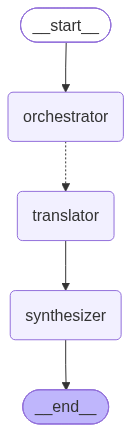

LangGraph multi-language translator compiled successfully.


In [17]:
# === Build the Graph ===
workflow = StateGraph(TranslatorState)

# Add nodes
workflow.add_node("orchestrator", orchestrator_node)
workflow.add_node("translator", translator_node)
workflow.add_node("synthesizer", synthesizer_node)

# Add edges
workflow.add_edge(START, "orchestrator")

# Conditional edge that dynamically creates workers via Send()
workflow.add_conditional_edges(
    "orchestrator",
    dispatch_translators,
    ["translator"]  # Possible targets of Send()
)

# All workers converge on synthesizer
workflow.add_edge("translator", "synthesizer")
workflow.add_edge("synthesizer", END)

# Compile
multi_translator = workflow.compile()

# Display the graph
display(Image(multi_translator.get_graph().draw_mermaid_png()))
print("LangGraph multi-language translator compiled successfully.")

**Understanding the Graph Visualization:**

The diagram shows the orchestrator workflow structure:

```
START → orchestrator → (conditional) → translator → synthesizer → END
```

The "(conditional)" part is returned by the `dispatch_translators()` function. At runtime:
- If the user requests 2 languages → 2 translator instances are created
- If the user requests 5 languages → 5 translator instances are created

All translator instances run in parallel, and their outputs aggregate into `state["translations"]` before the synthesizer runs.

**The Flow:**
1. `START` → orchestrator: Parse request, create plan
2. orchestrator → (dispatch): Return a `Send()` call for each task
3. (parallel) translator × N: Each translates one language
4. translator → synthesizer: Aggregated translations arrive
5. synthesizer → `END`: Format and return final output

### Step 4: Test the Multi-Language Translator

Let's test with the same requests we used for the OpenAI Agent SDK example to see the same dynamic behavior.

#### Run the Following Cell

In [18]:
# Test Request A: Three languages
lg_request_a = "Help translate 'to do the greatest good' into Arabic, French, and Japanese."

display(Markdown(f"# Test Request A: Three Languages\n\n**Request:** {lg_request_a}"))

result_a = multi_translator.invoke({"request": lg_request_a})

display(Markdown(f"**Tasks identified:** {len(result_a['tasks'])}"))
display(Markdown("## Translations\n\n" + result_a["final_output"]))

# Test Request A: Three Languages

**Request:** Help translate 'to do the greatest good' into Arabic, French, and Japanese.

**Tasks identified:** 3

## Translations

**Arabic:** لتحقيق أعظم خير  
**French:** faire le plus grand bien  
**Japanese:** 最大の善をなすため

#### Run the Following Cell

In [19]:
# Test Request B: Two languages
lg_request_b = "Please translate 'The weather is beautiful today' into Spanish and German."

display(Markdown(f"# Test Request B: Two Languages\n\n**Request:** {lg_request_b}"))

result_b = multi_translator.invoke({"request": lg_request_b})

display(Markdown(f"**Tasks identified:** {len(result_b['tasks'])}"))
display(Markdown("## Translations\n\n" + result_b["final_output"]))

# Test Request B: Two Languages

**Request:** Please translate 'The weather is beautiful today' into Spanish and German.

**Tasks identified:** 2

## Translations

**Spanish:** El clima está hermoso hoy.  
**German:** Das Wetter ist heute schön.

## Implement the Report Generator With LangGraph

Now you'll implement the **report generator** using LangGraph's `Send` API.

There are two code cells below.

* In the first code cell, the schema, state, and most node functions have been defined for you.
* In the second code cell, your task is to complete the `dispatch_writers()` function to dynamically create section writer workers using `Send`.

    **Hint:** Look at the implementation of the `dispatch_translators()` function in the example above. You need to return a list of `Send` objects, one for each section in `state["sections"]`. Each `Send()` call should:
    - Target the `"section_writer"` node
    - Pass `{"section": section}` as the worker's state

#### Run the Following Cell

In [20]:
# === Section Schema (for structured output) ===
class SectionPlan(BaseModel):
    """A planned section of the report."""
    name: str = Field(description="Section title")
    description: str = Field(description="What to cover in this section")

class ReportSections(BaseModel):
    """The planned sections for the report."""
    sections: List[SectionPlan] = Field(description="List of sections")


# === Main Workflow State ===
class ReportState(TypedDict):
    topic: str                                              # Input topic
    sections: list[SectionPlan]                             # Planned sections
    completed_sections: Annotated[list, operator.add]       # Workers write here (AGGREGATED)
    final_report: str                                       # Final synthesized report


# === Worker State (what each writer receives) ===
class WriterState(TypedDict):
    section: SectionPlan                                    # The section to write
    completed_sections: Annotated[list, operator.add]       # Worker writes its output here


# Create planner with structured output
report_planner = llm.with_structured_output(ReportSections)


# === Planner Node ===
def report_planner_node(state: ReportState):
    """Plan the report sections."""
    result = report_planner.invoke([
        SystemMessage(content="Create a plan for a report with 2-4 sections. Each section needs a name and description."),
        HumanMessage(content=f"Topic: {state['topic']}")
    ])
    return {"sections": result.sections}


# === Section Writer Node (Worker) ===
def section_writer_node(state: WriterState):
    """Write a single section of the report."""
    section = state["section"]
    
    result = llm.invoke([
        SystemMessage(content="Write a report section (2-3 paragraphs). Use markdown with ## for the title."),
        HumanMessage(content=f"Section: {section.name}\nCover: {section.description}")
    ])
    
    # Return to completed_sections (will be aggregated with other workers)
    return {"completed_sections": [result.content]}


# === Synthesizer Node ===
def report_synthesizer_node(state: ReportState):
    """Combine all sections into a final report."""
    sections_text = "\n\n---\n\n".join(state["completed_sections"])
    
    result = llm.invoke([
        SystemMessage(content="Combine these sections into a cohesive report. Add a brief intro and conclusion."),
        HumanMessage(content=f"Topic: {state['topic']}\n\nSections:\n{sections_text}")
    ])
    
    return {"final_report": result.content}


print("All report nodes defined: planner, section_writer, synthesizer")

All report nodes defined: planner, section_writer, synthesizer


In the code cell below, replace the line `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

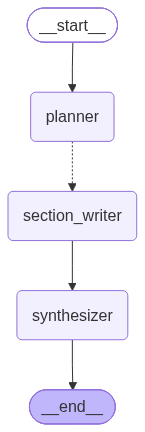

Report generator compiled successfully.


In [21]:
# === Dispatch Function (Dynamic Worker Creation) ===
def dispatch_writers(state: ReportState):
    """Create a section writer worker for each section in the plan.
    
    Return a list of Send() objects, one for each section.
    Each Send should target "section_writer" node and pass {"section": section}
    """
    return [Send("section_writer", {"section": section}) for section in state["sections"]]


# === Build the Graph ===
report_workflow = StateGraph(ReportState)

# Add nodes
report_workflow.add_node("planner", report_planner_node)
report_workflow.add_node("section_writer", section_writer_node)
report_workflow.add_node("synthesizer", report_synthesizer_node)

# Add edges
report_workflow.add_edge(START, "planner")

# Dynamic dispatch to section writers
report_workflow.add_conditional_edges(
    "planner",
    dispatch_writers,
    ["section_writer"]
)

report_workflow.add_edge("section_writer", "synthesizer")
report_workflow.add_edge("synthesizer", END)

# Compile
report_generator = report_workflow.compile()

display(Image(report_generator.get_graph().draw_mermaid_png()))
print("Report generator compiled successfully.")

<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">
<pre>
    return [Send("section_writer", {"section": section}) for section in state["sections"]]

</pre>
</p>

</details>

### Test Your Report Generator

Run the cells below to test with two different topics.

#### Run the Following Cell

In [22]:
# Test Topic A: Historical/cultural topic
lg_topic_a = "The History of Coffee"

display(Markdown(f"# Test Topic A\n\n**Topic:** {lg_topic_a}"))

lg_report_a = report_generator.invoke({"topic": lg_topic_a})

display(Markdown(f"**Sections planned:** {len(lg_report_a['sections'])}"))
display(Markdown("## Final Report\n\n---"))
display(Markdown(lg_report_a["final_report"]))

# Test Topic A

**Topic:** The History of Coffee

**Sections planned:** 3

## Final Report

---

**The History of Coffee**

### Introduction

Coffee, one of the world’s most beloved beverages, boasts a rich and intricate history that spans continents and centuries. What began as the discovery of energizing berries in the Ethiopian highlands has evolved into a complex global industry, shaping cultures, economies, and social life around the globe. This report traces the origins of coffee, its journey across continents, and the profound impacts it has had on societies worldwide.

---

### Origins of Coffee

The story of coffee begins in the highlands of Ethiopia, where, according to popular legend, a goatherd named Kaldi noticed his goats becoming unusually energetic after eating bright red berries from a mysterious shrub. Intrigued by the effect, Kaldi tasted the berries himself and soon experienced a newfound sense of vitality. News of these "magic" beans spread to local monks, who began using them to stave off drowsiness during long hours of prayer, thus establishing coffee’s early reputation for promoting wakefulness.

From Ethiopia, coffee gradually found its way across the Red Sea to the Arabian Peninsula. By the 15th century, it was being cultivated and traded in Yemen, where Sufi mystics brewed a beverage called "qahwa" to sustain them through their spiritual rituals. This marked the dawn of coffee’s cultural significance, especially as coffeehouses (“qahveh khaneh”) began to flourish in cities like Mecca and Medina. These early coffeehouses quickly became hubs for social interaction, intellectual conversation, and political discourse—a role that would only expand as coffee spread throughout the Middle East and beyond.

---

### Coffee’s Global Expansion

Coffee’s emergence as a global commodity is a testament to centuries of trade, exploration, and cross-cultural exchange. Initially cultivated in Ethiopia and popularized in Yemen, coffee traveled along established trade routes to Egypt, the Ottoman Empire, and the wider Islamic world. Ottoman merchants were instrumental in establishing coffeehouses in major cities such as Constantinople (Istanbul) and Damascus during the 16th century, further embedding coffee into urban social and political life.

Europe encountered coffee in the 17th century, introduced primarily by Venetian traders with connections to the Ottoman Empire. The beverage rapidly gained popularity, and "penny universities"—as European coffeehouses were dubbed—sprang up in cities from London to Vienna. These venues attracted thinkers, artists, and politicians, becoming fertile ground for intellectual movements such as the Enlightenment.

To break the Arab monopoly on coffee production, European colonial powers began cultivating coffee in their overseas territories. The Dutch introduced coffee to Java in Indonesia, while the French established plantations in the Caribbean. The spread continued to Latin America and Africa, with countries like Brazil and Colombia eventually becoming coffee-producing giants. Wherever it took root, coffee adapted to local preferences, influencing customs and traditions and becoming an essential part of daily life around the world.

---

### The Cultural and Economic Impact of Coffee

Beyond its role as a stimulating beverage, coffee has acted as a catalyst for social change and economic development. The rise of coffeehouses in the Middle East and Europe revolutionized communal life, offering new spaces for discussion, debate, and creative exchange. These establishments became meeting grounds for philosophers, writers, merchants, and political dissenters, playing a significant role in shaping Enlightenment thought and the modern public sphere.

Economically, coffee stands as one of the world’s most valuable traded commodities, second only to oil among legal goods. Its cultivation supports millions of farmers and workers in Latin America, Africa, and Southeast Asia, forming the backbone of many developing economies. Yet, the economics of coffee are complex and sometimes inequitable, with powerful consuming nations and multinational corporations often controlling prices and terms of trade. In response, movements such as fair trade and direct trade are seeking to address issues of sustainability, fairness, and transparency, underscoring coffee’s ongoing importance as both a product and a driver of change.

---

### Conclusion

From its mystical Ethiopian origins to its prominence in coffeehouses and global markets today, coffee’s history is rich with stories of innovation, adaptation, and transformation. It has played— and continues to play— a vital role in shaping cultural rituals, social institutions, and the global economy. As coffee continues to evolve, embracing new movements for ethical and sustainable production, its legacy endures as a symbol of connection, energy, and shared human experience.

#### Run the Following Cell

In [23]:
# Test Topic B: Technical/scientific topic
lg_topic_b = "How Solar Panels Work"

display(Markdown(f"# Test Topic B\n\n**Topic:** {lg_topic_b}"))

lg_report_b = report_generator.invoke({"topic": lg_topic_b})

display(Markdown(f"**Sections planned:** {len(lg_report_b['sections'])}"))
display(Markdown("## Final Report\n\n---"))
display(Markdown(lg_report_b["final_report"]))

# Test Topic B

**Topic:** How Solar Panels Work

**Sections planned:** 3

## Final Report

---

**How Solar Panels Work: A Comprehensive Overview**

### Introduction

As the world faces rising concerns about climate change and depletion of fossil fuels, the importance of renewable energy solutions has never been greater. Solar panels, which harness energy directly from the sun, are at the forefront of this green revolution. Their widespread adoption is helping lead the transition towards a more sustainable and resilient energy future. In this report, we explore how solar panels work, the science behind their function, and the essential components that comprise a typical solar panel system.

---

### Introduction to Solar Panels

Solar panels are devices designed to capture sunlight and convert it into usable electricity. They play a central role in the shift towards renewable energy by harnessing an abundant and clean resource—the sun. At their core, solar panels are made up of photovoltaic (PV) cells, which are typically composed of semiconductor materials such as silicon. These cells absorb photons from sunlight, inducing an electrical current through the photovoltaic effect. The panels are often mounted on rooftops or in large-scale solar farms, and their modular nature means that systems can be scaled from powering a single home to providing electricity for entire communities.

The importance of solar panels in today's energy landscape cannot be overstated. As concerns about climate change and fossil fuel depletion grow, the need for sustainable and eco-friendly energy sources becomes more urgent. Solar panels offer a solution that is both renewable and reduces greenhouse gas emissions. Their widespread adoption contributes significantly to energy independence, lowers electricity costs over time, and supports global efforts to transition to cleaner energy sources. This makes solar panels a cornerstone technology in the move toward a more sustainable and resilient energy future.

---

### The Science Behind Solar Panels

Solar panels are innovative devices that convert sunlight directly into electricity through a process known as the photovoltaic effect. At the core of a solar panel are numerous photovoltaic (PV) cells, usually made from semiconductor materials like silicon. When sunlight strikes these cells, photons (light particles) transfer their energy to electrons within the semiconductor material. This energy excites the electrons, allowing them to break free from their atoms and flow through the material as an electric current. This flow of electrons is harnessed as direct current (DC) electricity, which can then be converted into alternating current (AC) for use in homes and businesses.

The efficiency of solar panels is largely determined by the quality of the semiconductor materials and the design of the PV cells. Most commercially available solar panels use crystalline silicon due to its durability and favorable electronic properties. However, research continues into alternative materials such as thin-film technologies and perovskite cells, which promise to further improve the efficiency and affordability of solar power. By understanding and optimizing the photovoltaic effect, engineers are continually enhancing the ability of solar panels to capture and convert solar energy, making this technology a cornerstone of the transition to renewable energy sources.

---

### Components and Operation of a Solar Panel System

A typical solar panel system is composed of several key components that work in unison to capture sunlight and convert it into usable electricity. The primary element is the solar panel itself, which consists of numerous solar cells made from semiconductor materials like silicon. These solar cells generate direct current (DC) electricity when exposed to sunlight through the photovoltaic effect. The panels are mounted on supporting structures, often installed on rooftops or in open fields, with the mounting system engineered to secure the panels at an optimal angle for maximum solar exposure. Some systems also include tracking mechanisms that follow the sun’s path, further enhancing energy collection efficiency.

Once the solar panels produce DC electricity, it must be converted into alternating current (AC) to be compatible with household appliances and the electrical grid. This conversion is performed by an inverter, a crucial component in any solar power system. Modern systems typically employ either a centralized inverter for an entire array or microinverters attached to individual panels, improving both efficiency and reliability. Additional balance-of-system (BOS) components, such as wiring, safety disconnects, and monitoring devices, are also integrated to ensure safe operation and performance tracking. Together, these elements form an interconnected system that efficiently harnesses solar energy, converts it to usable power, and delivers electricity to homes, businesses, or the broader grid.

---

### Conclusion

Solar panels represent a pivotal technology in our global pursuit of clean, renewable energy. By capturing sunlight and converting it into electricity through advanced scientific principles and well-designed systems, solar panels reduce our dependence on fossil fuels and lower harmful emissions. Ongoing innovations in photovoltaic materials and system components continue to enhance the efficiency, affordability, and accessibility of solar energy. As adoption increases, solar panels will play an increasingly vital role in building a sustainable future for generations to come.

---

## Reflection: Orchestrator Workflow

You've now implemented the **orchestrator workflow** pattern using two different frameworks. Take a moment to reflect on what you've learned.

### When to Use Orchestrator vs. Parallelization

The key distinction:

| Question | If Yes → Use... |
|----------|-----------------|
| Are the subtasks known at design time? | Parallelization |
| Does the LLM need to decide what tasks to run? | Orchestrator |
| Is the number of workers always the same? | Parallelization |
| Does the number of workers depend on the input? | Orchestrator |

As the LangGraph documentation notes: orchestrator workflows are for when "subtasks cannot be predefined the way they can with parallelization."

### Structured Output for Planning

Both frameworks require the orchestrator to output **structured data** that you can iterate over:

```python
# Pydantic model defines the structure
class TranslationPlan(BaseModel):
    tasks: List[TranslationTask]

# Orchestrator outputs this structure
plan = orchestrator.invoke(request)
for task in plan.tasks:  # Now we can iterate
    call_worker(task)
```

Without structured output, you'd have to parse free-form text to extract the tasks. Structured output makes the plan programmatically accessible.

### SDK vs. LangGraph: Calling Predefined Agents vs. Dynamic Worker Creation

| Aspect | OpenAI Agents SDK | LangGraph |
|--------|-------------------|----------|
| Worker mechanism | Call predefined agent multiple times | `Send()` creates worker instances |
| Worker definition | Agent defined once, called N times | Node function runs N parallel instances |
| Aggregation | Manual: collect results in a list | Automatic: `Annotated[list, operator.add]` |
| Worker state | Via function arguments | Isolated via `Send()` payload |
| Graph structure | Implicit in code | Explicit in graph definition |

Both achieve the same goal. The SDK gives you more explicit control over calling agents. LangGraph provides built-in primitives that handle parallel execution and aggregation automatically.

### Handoffs vs. Agents as Tools

Remember the two multi-agent patterns in the OpenAI Agents SDK:

1. **Handoffs** (Peer pattern): Control transfers completely to another agent. The original agent doesn't get control back. Use for specialist takeover scenarios.

2. **Agents as Tools** (Manager pattern): The orchestrator calls workers and gets results back. It stays in control. Use for result aggregation scenarios.

### The Two-Layer Prompt Stack

A useful architecture is to have a base system prompt for the workers that can be dynamically altered during runtime:

1. **Worker base system prompt** (static): Describes capabilities and guardrails
2. **Orchestrator overlay** (dynamic): Injected at runtime with specific task details

```python
# Base prompt (static)
translator_agent = Agent(
    instructions="You are an expert translator..."
)

# Overlay (dynamic, from orchestrator's plan)
await Runner.run(translator_agent, f"Translate to {task.language}: {task.text}")
```

This allows one worker definition to handle many different tasks based on what the orchestrator needs.

### Looking Ahead

We've covered workflows that execute once: plan, run workers, synthesize, done. But what if the output isn't good enough? What if you need to evaluate the result and try again?

That's where **plan reflection (evaluator-optimizer)** comes in, which is the final pattern you'll explore in the next activity.